In [70]:
import pandas as pd
import numpy as np


In [71]:
df = pd.read_json("data.json")


In [72]:
df.head(10)

,id,patient_id,experiment_id,data
0,d42a50c2-4b99-11f1-9802-04d4c449342f,1,2,"{'accuracy': 3, 'data': [-4.4285164, 4.368098,..."
1,d42ac5f9-4b99-11f1-ba85-04d4c449342f,1,2,"{'accuracy': 3, 'data': [-3.7010984000000002, ..."
2,d42b3b57-4b99-11f1-a0d7-04d4c449342f,1,2,"{'accuracy': 3, 'data': [-4.4231324, 3.612564,..."
3,d42bd763-4b99-11f1-b21c-04d4c449342f,1,2,"{'accuracy': 3, 'data': [-3.7854455, 4.1383867..."
4,d42c2536-4b99-11f1-adaf-04d4c449342f,1,2,"{'accuracy': 3, 'data': [-4.135994, 4.0869412,..."
5,d42c4c36-4b99-11f1-bc16-04d4c449342f,1,2,"{'accuracy': 3, 'data': [-3.9852461999999997, ..."
6,d42c734f-4b99-11f1-8b53-04d4c449342f,1,2,"{'accuracy': 3, 'data': [-4.159324, 4.1431723,..."
7,d42c9a5d-4b99-11f1-aa94-04d4c449342f,1,2,"{'accuracy': 3, 'data': [-3.993621, 3.545565, ..."
8,d42c9a5e-4b99-11f1-8c51-04d4c449342f,1,2,"{'accuracy': 3, 'data': [-4.1557345, 4.165306,..."
9,d42cc16a-4b99-11f1-8ca9-04d4c449342f,1,2,"{'accuracy': 3, 'data': [-4.086343, 3.675974, ..."


In [73]:
data_1 = df["data"]

In [74]:
data_1[0]

data = data_1.tolist()

In [75]:
df = pd.json_normalize(data)
df[["x", "y", "z"]] = pd.DataFrame(df["data"].tolist(), index=df.index)

In [76]:
# parse time
df["friendlyTimeStamp"] = pd.to_datetime(df["friendlyTimeStamp"])

# signal magnitude
df["magnitude"] = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)

df["avg_magnitude_10"] = df["magnitude"].rolling(window=10).mean()
df["avg_magnitude_50"] = df["magnitude"].rolling(window=50).mean()

print(df)

     accuracy                                        data             device  \
0           3             [-4.4285164, 4.368098, 6.83091]  samsung SM-G990B2   
1           3   [-3.7010984000000002, 4.188038, 8.108678]  samsung SM-G990B2   
2           3  [-4.4231324, 3.612564, 7.5463643000000005]  samsung SM-G990B2   
3           3           [-3.7854455, 4.1383867, 8.081161]  samsung SM-G990B2   
4           3            [-4.135994, 4.0869412, 7.553543]  samsung SM-G990B2   
..        ...                                         ...                ...   
710         3          [-0.90089774, 2.539383, 8.2145605]  samsung SM-G990B2   
711         3           [-1.6683956, 2.0201404, 7.893324]  samsung SM-G990B2   
712         3           [-0.79441714, 2.4364917, 8.55135]  samsung SM-G990B2   
713         3            [-1.253839, 3.1627133, 8.763713]  samsung SM-G990B2   
714         3           [-2.2947168, 2.5896323, 8.301898]  samsung SM-G990B2   

     experimentId       friendlyTimeSta

In [77]:
mag = df["magnitude"]

Text(0.5, 0, 'Time')

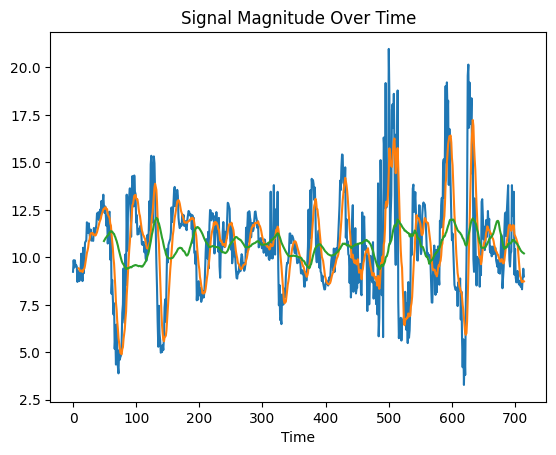

In [78]:
import matplotlib.pyplot as plt
plt.plot(mag)
plt.plot(df["avg_magnitude_10"], label="Average Magnitude (10)")
plt.plot(df["avg_magnitude_50"], label="Average Magnitude (50)")
plt.title("Signal Magnitude Over Time")
plt.xlabel("Time")